In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('ToyotaCorolla-MLR.csv')

In [3]:
# Summary statistics
print("Summary Statistics:")
print(df.describe())

Summary Statistics:
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112  
min   

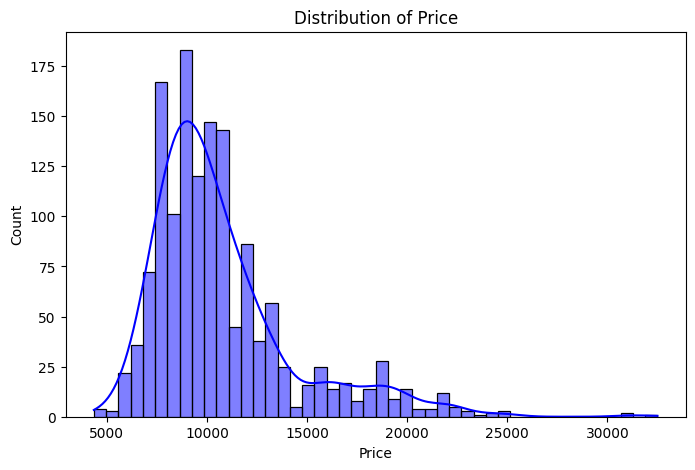

In [4]:
# Visualizing the distribution of the target variable 'Price'
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Price')
plt.show()

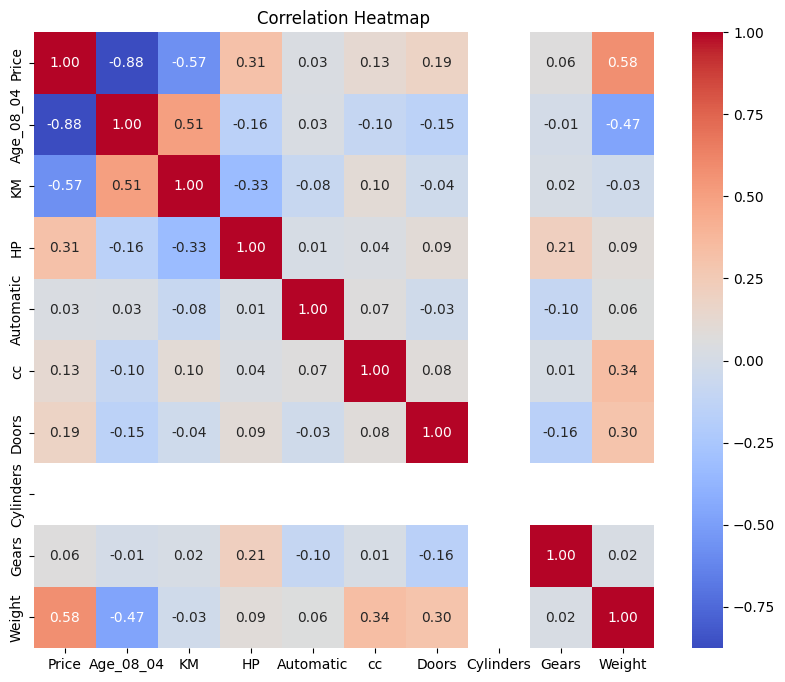

In [5]:
# Correlation Heatmap to see relationships between variables
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [6]:
# 1. Handle Categorical Data: Convert Fuel_Type to dummy variables
df_encoded = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [7]:
# 2. Drop constant columns: 'Cylinders' has only one unique value (4) and won't help the model
df_encoded = df_encoded.drop('Cylinders', axis=1)

In [8]:
# Target: Price, Features: All others
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Scaling data (required for Lasso, Ridge, and better interpretation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Model 1: Using all available features
model1 = LinearRegression()
model1.fit(X_train, y_train)# Model 1: Using all available features
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [11]:
# Model 2: Feature Selection (Using only top correlated features: Age, KM, HP, Weight)
selected_features = ['Age_08_04', 'KM', 'HP', 'Weight']
model2 = LinearRegression()
model2.fit(X_train[selected_features], y_train)

LinearRegression()

In [12]:
# Model 3: Model 1 features with scaling (to compare coefficient magnitudes)
model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)

LinearRegression()

In [13]:
# Interpret coefficients for Model 1
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
print("\nModel 1 Coefficients:\n", coeffs)


Model 1 Coefficients:
             Feature  Coefficient
0         Age_08_04  -120.830458
1                KM    -0.016231
2                HP    14.039479
3         Automatic   148.830927
4                cc    -0.030372
5             Doors   -60.310974
6             Gears   551.600710
7            Weight    25.884958
8  Fuel_Type_Diesel   -68.548757
9  Fuel_Type_Petrol  1370.808910


In [14]:
# --- 4. Evaluate Models ---
def get_metrics(model, X_v, y_v):
    preds = model.predict(X_v)
    mae = mean_absolute_error(y_v, preds)
    rmse = np.sqrt(mean_squared_error(y_v, preds))
    r2 = r2_score(y_v, preds)
    return mae, rmse, r2

m1_metrics = get_metrics(model1, X_test, y_test)
m2_metrics = get_metrics(model2, X_test[selected_features], y_test)
m3_metrics = get_metrics(model3, X_test_scaled, y_test)

print(f"\nModel 1 Metrics - MAE: {m1_metrics[0]:.2f}, RMSE: {m1_metrics[1]:.2f}, R2: {m1_metrics[2]:.4f}")
print(f"Model 2 Metrics - MAE: {m2_metrics[0]:.2f}, RMSE: {m2_metrics[1]:.2f}, R2: {m2_metrics[2]:.4f}")


Model 1 Metrics - MAE: 990.89, RMSE: 1484.27, R2: 0.8349
Model 2 Metrics - MAE: 1001.20, RMSE: 1411.85, R2: 0.8506


In [15]:
# --- 5. Apply Lasso and Ridge ---
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

lasso_metrics = get_metrics(lasso, X_test_scaled, y_test)
ridge_metrics = get_metrics(ridge, X_test_scaled, y_test)

print(f"\nLasso Metrics - MAE: {lasso_metrics[0]:.2f}, RMSE: {lasso_metrics[1]:.2f}, R2: {lasso_metrics[2]:.4f}")
print(f"Ridge Metrics - MAE: {ridge_metrics[0]:.2f}, RMSE: {ridge_metrics[1]:.2f}, R2: {ridge_metrics[2]:.4f}")


Lasso Metrics - MAE: 991.02, RMSE: 1483.24, R2: 0.8351
Ridge Metrics - MAE: 990.86, RMSE: 1483.56, R2: 0.8350
